<a href="https://colab.research.google.com/github/joshyajith863/Deep-learning-dl-lab/blob/main/nifty50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed

Epoch 1/50



C:\Users\Student\.conda\envs\nifty50\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0267
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0261
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0140
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041
Epoch 13/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039
Epoch 14/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038
Epoch 15/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039
Epoch 16/50
68/68 ━━━━━━━━━━━━

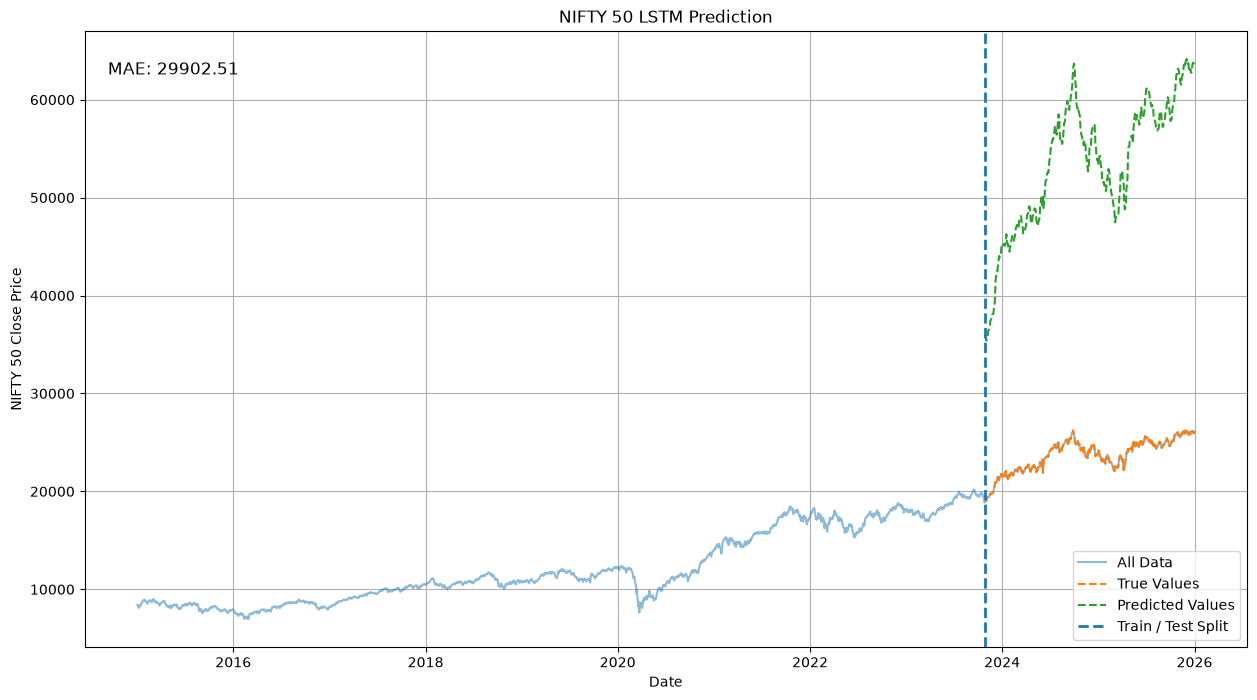

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error


# Download NIFTY 50 data
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close"]].dropna()


# Scale data
scaler = MinMaxScaler()
data = scaler.fit_transform(df)


# Create sequences
look_back = 20
X, y = [], []

for i in range(len(data) - look_back):
    X.append(data[i:i + look_back])
    y.append(data[i + look_back, 3])

X = np.array(X)
y = np.array(y)


# Train-test split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# LSTM model
model = Sequential([
    LSTM(64, input_shape=(look_back, 4)),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


# Train
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(
            monitor="loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)


# Predict
pred = model.predict(X_test, verbose=0).flatten()


# Convert predictions back to original price
temp = np.zeros((len(pred), 4))
temp[:, 3] = pred
pred = scaler.inverse_transform(temp)[:, 3]

temp = np.zeros((len(y_test), 4))
temp[:, 3] = y_test
actual = scaler.inverse_transform(temp)[:, 3]


# Calculate MAE
mae = mean_absolute_error(actual, pred)

print("Mean Absolute Error (MAE):", mae)


# Test dates
dates = df.index[split + look_back:]

# Split date
split_date = dates[0]


# Plot
plt.figure(figsize=(15, 8))

# All data
plt.plot(
    df.index,
    df["Close"],
    label="All Data",
    alpha=0.5
)

# True values
plt.plot(
    dates,
    actual,
    label="True Values",
    linestyle="--"
)

# Predicted values
plt.plot(
    dates,
    pred,
    label="Predicted Values",
    linestyle="--"
)

# Train/Test split line
plt.axvline(
    x=split_date,
    linestyle="--",
    linewidth=2,
    label="Train / Test Split"
)

# Display MAE on graph
plt.text(
    0.02,
    0.95,
    f"MAE: {mae:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.xlabel("Date")
plt.ylabel("NIFTY 50 Close Price")
plt.title("NIFTY 50 LSTM Prediction")

plt.legend()
plt.grid(True)

plt.show()

